In [ ]:
pip install ucimlrepo

In [ ]:
# Some imports we will need
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets
data = heart_disease.data.original


In [ ]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


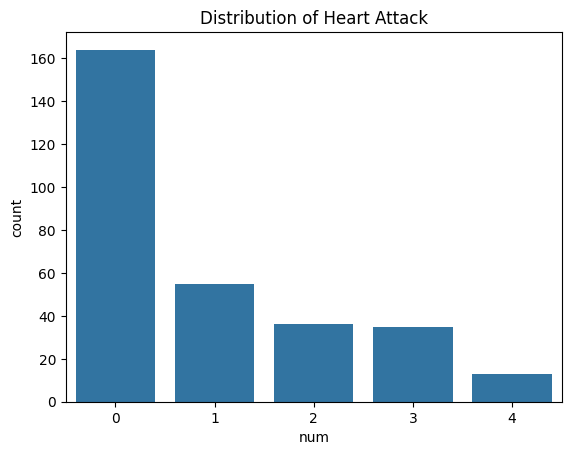

In [ ]:
# Explore the distribution of the target variable
sns.countplot(x='num', data=y)
plt.title('Distribution of Heart Attack')
plt.show()

In [ ]:
y.num = np.where(y.num > 1, 1, y.num)

<ipython-input-4-d049ea3f728d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.num = np.where(y.num > 1, 1, y.num)


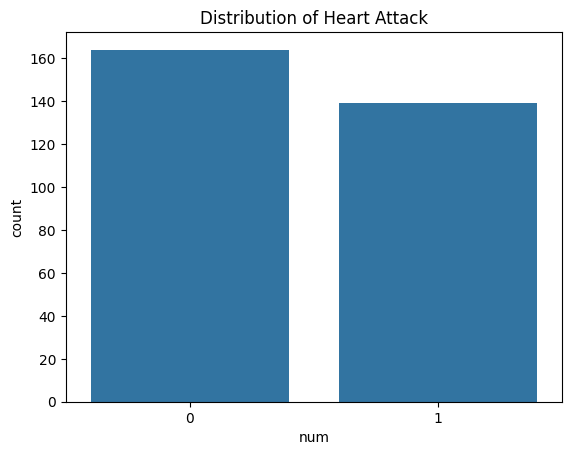

In [ ]:
sns.countplot(x='num', data=y)
plt.title('Distribution of Heart Attack')
plt.show()

In [ ]:
# Check for missing values
print(X.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [ ]:
data = data.dropna(axis=0)


In [ ]:
X = pd.DataFrame(data.iloc[:, 1:-1])
Y = pd.DataFrame(data.iloc[:, -1])

In [ ]:
from sklearn.preprocessing import StandardScaler


# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
disease_threshold = 1
Y[Y >= disease_threshold] = 1
data.num[data.num >= disease_threshold] = 1

<ipython-input-51-12e24a978c61>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.num[data.num >= disease_threshold] = 1


In [ ]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1


In [ ]:
print(Y.values.ravel())

[0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 0 1
 1 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 1 0 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1
 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1
 0 1 1 0 0 0 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 1 1 0 0
 0 0 0 0 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 0
 1 1 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1
 0 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1
 0 0 1 1 1 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 1 1
 1]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test, data_train, data_test = train_test_split(X, Y, data, test_size=0.2, random_state=42)

## Gaussian naive Bayes

In [ ]:
import numpy as np

def gaussian_naive_bayes_ml(X, y):

    n_samples, n_features = X.shape

    # Compute the priors
    prior0 = np.mean(y == 0)
    prior1 = 1 - prior0

    # Separate data by class
    X0 = X[X.num == 0]
    X1 = X[X.num == 1]

    # Compute the class-conditional means
    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)

    # Compute the class-conditional variances
    sigma0_sq = np.var(X0, axis=0)
    sigma1_sq = np.var(X1, axis=0)

    return mu1, mu0, sigma1_sq, sigma0_sq, prior0, prior1

In [ ]:
mu1, mu0, sigma1_sq, sigma0_sq, prior0, prior1 = gaussian_naive_bayes_ml(data_train, Y_train)

In [ ]:
print("mu1: ", mu1)
print("mu0: ", mu0)
print("sigma1_sq: ", sigma1_sq)
print("sigma0_sq: ", sigma0_sq)
print("q: ", prior0)
print("1-q: ", prior1)

mu1:  age          56.663717
sex           0.831858
cp            3.566372
trestbps    135.557522
chol        254.796460
fbs           0.141593
restecg       1.185841
thalach     138.761062
exang         0.557522
oldpeak       1.530088
slope         1.796460
ca            1.150442
thal          5.796460
num           1.000000
dtype: float64
mu0:  age          52.741935
sex           0.580645
cp            2.846774
trestbps    129.241935
chol        242.685484
fbs           0.177419
restecg       0.911290
thalach     157.338710
exang         0.161290
oldpeak       0.589516
slope         1.451613
ca            0.258065
thal          3.862903
num           0.000000
dtype: float64
sigma1_sq:  age           60.630276
sex            0.139870
cp             0.705772
trestbps     369.131647
chol        2575.719633
fbs            0.121544
restecg        0.947764
thalach      531.916360
exang          0.246691
oldpeak        1.576971
slope          0.303704
ca             1.012765
thal          

In [ ]:
import numpy as np

def log_likelihood_ratio(x, mu1, mu0, sigma1_sq, sigma0_sq):
    if len(x.shape) == 1:
      log_p_X_given_1 = np.sum(-0.5 * np.log(2 * np.pi) - 0.5 * np.log(sigma1_sq) - ((x - mu1) ** 2)
                                 / (2 * sigma1_sq))
      log_p_X_given_0 = np.sum(-0.5 * np.log(2 * np.pi) - 0.5 * np.log(sigma0_sq) - ((x - mu0) ** 2)
                                 / (2 * sigma0_sq))
    else:
        log_p_X_given_1 = np.sum(-0.5 * np.log(2 * np.pi) - 0.5 * np.log(sigma1_sq) - ((x - mu1) ** 2)
                                 / (2 * sigma1_sq), axis=1)
        log_p_X_given_0 = np.sum(-0.5 * np.log(2 * np.pi) - 0.5 * np.log(sigma0_sq) - ((x - mu0) ** 2)
                                 / (2 * sigma0_sq), axis=1)

    return log_p_X_given_1 - log_p_X_given_0

In [ ]:
print("log-likelihood_ratio: ", log_likelihood_ratio(data_test, mu1, mu0, sigma1_sq, sigma0_sq))

log-likelihood_ratio:  169    -8.757182
214    -5.146303
63      4.877615
155    13.416719
5      -9.899234
77     -5.471584
185    -7.157831
159    -0.252459
9      30.891930
140    -4.018505
290     2.274745
78     -7.515698
93     -9.483937
102    -5.722216
42     -6.778148
225   -13.999637
288    -3.306627
33      1.452641
267    18.725329
149    -8.868510
248     3.062762
45      4.743949
60      5.768008
46     -5.156096
282    10.684884
240   -10.279432
177    14.056439
237     0.771017
17     -5.269156
283   -12.219269
112    -6.691089
222   -11.573726
24     16.922279
82     -9.816489
7      -4.282249
75     -8.802728
109     1.666853
84    -11.535427
91     33.880784
73      3.507490
117    -9.606469
127    13.778382
236    32.081668
59     -0.909892
198   -10.801327
211     5.192797
98     -8.186072
187    14.727906
178    -6.799588
125    -8.889251
94     -7.917953
299    27.879707
184    -6.712664
279    -2.915059
195     9.533169
297     8.084245
25     -5.849102
227    -

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
log_likelihood_ratios = log_likelihood_ratio(data_test, mu1, mu0, sigma1_sq, sigma0_sq)
decision_threshold = np.log(prior0 / prior1)
#print(log_likelihood_ratios)
#print(decision_threshold)
y_pred = (log_likelihood_ratios > decision_threshold).astype(int)

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()

tpr = tp / (tp + fn)  # True positive rate
fpr = fp / (fp + tn)  # False positive rate


print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(metrics.confusion_matrix(Y_test, y_pred))
#print(test_labels)
#print(y_pred)

True Positive Rate (TPR): 0.8333
False Positive Rate (FPR): 0.0278
[[35  1]
 [ 4 20]]


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
def calculate_tpr_fpr(p, ratio):
    n_pos = 100  # Assuming 100 positive samples
    n_neg = n_pos * ratio  # Varying negative samples based on ratio

    thresholds = np.linspace(0, 1, 1000)  # Generate thresholds

    tpr = []
    fpr = []

    for threshold in thresholds:
        tp = np.sum(p >= threshold)  # True positives
        fn = n_pos - tp  # False negatives

        tn = np.sum((1 - p) < threshold)  # True negatives
        fp = n_neg - tn  # False positives

        tpr.append(tp / n_pos)
        fpr.append(fp / n_neg)

    return tpr, fpr


In [ ]:
ratios = np.arange(1, 101, 10)  # Generate ratios from 1 to 100

tpr_all = []
fpr_all = []

for ratio in ratios:
    tpr, fpr = calculate_tpr_fpr(0.5, ratio)  # Assuming p = 0.5 (equal class sizes)
    tpr_all.append(tpr)
    fpr_all.append(fpr)


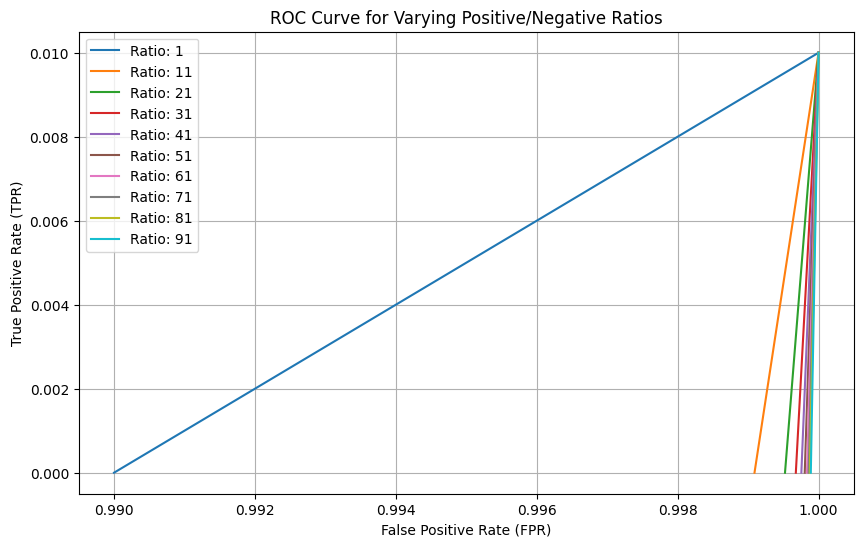

In [ ]:
plt.figure(figsize=(10, 6))  # Set figure size

for i, (tpr, fpr) in enumerate(zip(tpr_all, fpr_all)):
    plt.plot(fpr, tpr, label=f"Ratio: {ratios[i]}")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Varying Positive/Negative Ratios")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
log_likelihood_ratios = log_likelihood_ratio(data_test, mu1, mu0, sigma1_sq, sigma0_sq)
decision_threshold = np.log(prior0 / prior1 / 50)
#print(log_likelihood_ratios)
#print(decision_threshold)
y_pred = (log_likelihood_ratios > decision_threshold).astype(int)

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()

tpr = tp / (tp + fn)  # True positive rate
fpr = fp / (fp + tn)  # False positive rate


print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(metrics.confusion_matrix(Y_test, y_pred))
#print(test_labels)
#print(y_pred)

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


True Positive Rate (TPR): 0.9583
False Positive Rate (FPR): 0.3333
[[24 12]
 [ 1 23]]


## logistic regression

In [ ]:
# Standard Imports
import numpy as np
import matplotlib.pyplot as plt
# Imports to use for optimization
from functools import partial
import scipy.optimize

In [ ]:
# Set the regularization constant alpha=1e-6
alpha = 1e-6

# Define the sigmoid function
sigmoid = lambda z: 1 / (1 + np.exp(-z))

# Define the feature mappings
def linear_features(x):
    return np.column_stack([np.ones(x.shape[0]), x])

def diagonal_quadratic_features(x):
    linear = linear_features(x)
    quadratic = np.column_stack([x**2] + [np.ones(x.shape[0])])
    return np.column_stack([linear, quadratic])


In [ ]:
# Compute the objective function f(w) and its gradient ∇f(w)
def objective_func(w, x, y, feature_func):
    phi = feature_func(x)
    z = np.matmul(phi, w)
    p = sigmoid(z)
    negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    reg_term = (alpha / 2) * np.dot(w, w)
    return negloglik + reg_term

def gradient_func(w, x, y, feature_func):
    phi = feature_func(x)
    z = np.matmul(phi, w)
    p = sigmoid(z)
    grad = np.matmul(phi.T, p - y) + alpha * w
    return grad.reshape(-1)  # Reshape gradient to 1D vector


Feature set: linear_features


<ipython-input-44-152776c20c99>:6: RuntimeWarning: divide by zero encountered in log
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: invalid value encountered in multiply
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


 Train Loss: 84.9
 Train Accuracy: 0.835


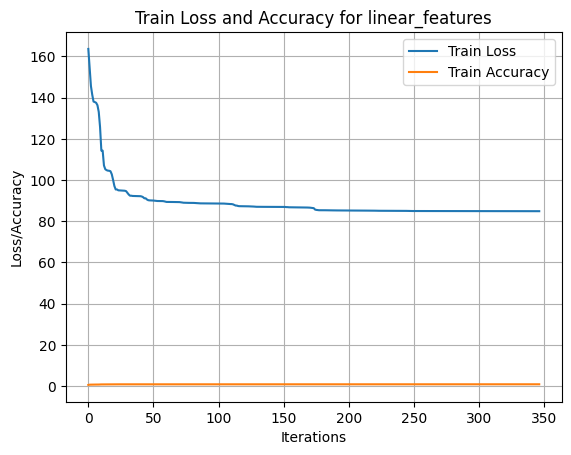


Feature set: diagonal_quadratic_features


<ipython-input-43-f4fe8513a270>:5: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda z: 1 / (1 + np.exp(-z))


 Train Loss: 122
 Train Accuracy: 0.743


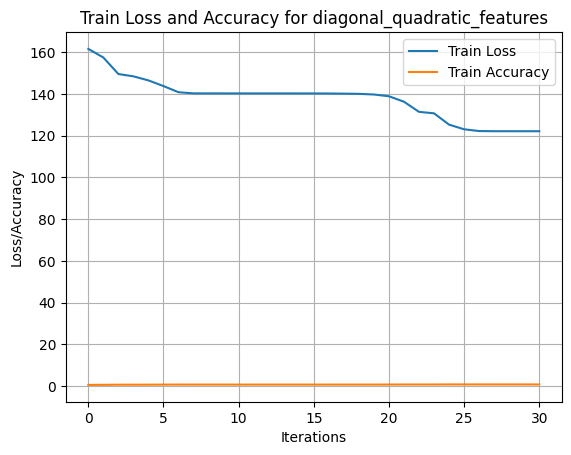

In [ ]:
#with data normalization


import matplotlib.pyplot as plt

# Train the logistic regression model for each feature set
loss_history = []  # Store train loss for each iteration
accuracy_history = []  # Store train accuracy for each iteration

for feature_func in [linear_features, diagonal_quadratic_features]:
    print(f"Feature set: {feature_func.__name__}")
    loss_func = partial(objective_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    grad_func = partial(gradient_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    phi = feature_func(X_train)
    w0 = np.zeros(phi.shape[1])
    options = dict()
    options["maxiter"] = 20000
    options["ftol"] = 1e-7

    # Track loss and accuracy during optimization
    def callback(w):
        z = np.matmul(feature_func(X_train), w)
        loss_history.append(loss_func(w))
        accuracy_history.append(np.mean(np.round(sigmoid(z)) == Y_train.values.ravel()))

    results = scipy.optimize.minimize(fun=loss_func, x0=w0, jac=grad_func, method="L-BFGS-B", options=options, callback=callback)
    assert(results.success)
    w_min = results.x

    # Calculate final train loss and accuracy
    train_loss = loss_func(w_min)
    z = np.matmul(feature_func(X_train), w_min)
    train_accuracy = np.mean(np.round(sigmoid(z)) == Y_train.values.ravel())

    print(f" Train Loss: {train_loss:.3g}")
    print(f" Train Accuracy: {train_accuracy:.3f}")

    # Plot train loss and accuracy (for this feature set)
    iterations = np.arange(len(loss_history))
    plt.plot(iterations, loss_history, label="Train Loss")
    plt.plot(iterations, accuracy_history, label="Train Accuracy")
    plt.xlabel("Iterations")
    plt.ylabel("Loss/Accuracy")
    plt.title(f"Train Loss and Accuracy for {feature_func.__name__}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Clear history for next iteration
    loss_history.clear()
    accuracy_history.clear()

    print()


In [ ]:
from sklearn.metrics import roc_curve

for feature_func in [linear_features, diagonal_quadratic_features]:
    print(f"Feature set: {feature_func.__name__}")
    loss_func = partial(objective_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    grad_func = partial(gradient_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    phi = feature_func(X_train)
    w0 = np.zeros(phi.shape[1])
    options = dict()
    options["maxiter"] = 20000
    options["ftol"] = 1e-7
    results = scipy.optimize.minimize(fun=loss_func, x0=w0, jac=grad_func, method="L-BFGS-B", options=options)
    assert(results.success)
    w_min = results.x
    train_loss = loss_func(w_min)
    z_train = np.matmul(feature_func(X_train), w_min)
    train_accuracy = np.mean(np.round(sigmoid(z_train)) == Y_train.values.ravel())

    # Evaluate on test set
    z_test = np.matmul(feature_func(X_test), w_min)
    test_accuracy = np.mean(np.round(sigmoid(z_test)) == Y_test.values.ravel())
    test_loss = objective_func(w_min, X_test, Y_test.values.ravel(), feature_func)

    # Calculate TPR and FPR on test set
    y_pred_proba = sigmoid(z_test)  # Predicted probabilities
    y_pred_proba = np.where(y_pred_proba < 0.5, 0, 1)
    #fpr, tpr, thresholds = roc_curve(Y_test.values.ravel(), y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(Y_test.values.ravel(), y_pred_proba).ravel()

    tpr = tp / (tp + fn)  # True positive rate
    fpr = fp / (fp + tn)  # False positive rate


    print(f" Train Loss: {train_loss:.3g}")
    print(f" Train Accuracy: {train_accuracy:.3f}")
    print(f" Test Loss: {test_loss:.3g}")
    print(f" Test Accuracy: {test_accuracy:.3f}")
    print(f" Test TPR: {tpr:.3f} ")  # Print TPR at the last threshold
    print(f" Test FPR: {fpr:.3f} ")  # Print FPR at the last threshold
    print()


Feature set: linear_features


<ipython-input-44-152776c20c99>:6: RuntimeWarning: divide by zero encountered in log
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: invalid value encountered in multiply
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


 Train Loss: 84.9
 Train Accuracy: 0.835
 Test Loss: 19.1
 Test Accuracy: 0.867
 Test TPR: 0.833 
 Test FPR: 0.111 

Feature set: diagonal_quadratic_features
 Train Loss: 122
 Train Accuracy: 0.743
 Test Loss: 25.2
 Test Accuracy: 0.767
 Test TPR: 0.708 
 Test FPR: 0.194 



<ipython-input-43-f4fe8513a270>:5: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda z: 1 / (1 + np.exp(-z))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: divide by zero encountered in log
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: invalid value encountered in multiply
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


Feature set: linear_features


<ipython-input-44-152776c20c99>:6: RuntimeWarning: divide by zero encountered in log
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: invalid value encountered in multiply
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


Feature set: diagonal_quadratic_features


<ipython-input-43-f4fe8513a270>:5: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda z: 1 / (1 + np.exp(-z))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: divide by zero encountered in log
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: invalid value encountered in multiply
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


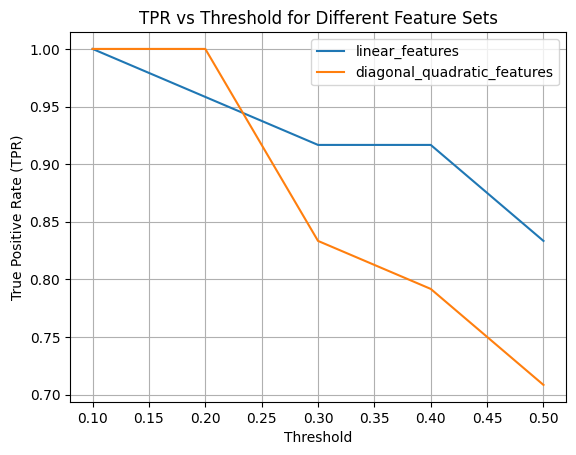

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

for feature_func in [linear_features, diagonal_quadratic_features]:
    print(f"Feature set: {feature_func.__name__}")
    loss_func = partial(objective_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    grad_func = partial(gradient_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    phi = feature_func(X_train)
    w0 = np.zeros(phi.shape[1])
    options = dict()
    options["maxiter"] = 20000
    options["ftol"] = 1e-7
    results = scipy.optimize.minimize(fun=loss_func, x0=w0, jac=grad_func, method="L-BFGS-B", options=options)
    assert(results.success)
    w_min = results.x
    train_loss = loss_func(w_min)
    z_train = np.matmul(feature_func(X_train), w_min)
    train_accuracy = np.mean(np.round(sigmoid(z_train)) == Y_train.values.ravel())

    # Evaluate on test set
    z_test = np.matmul(feature_func(X_test), w_min)
    test_accuracy = np.mean(np.round(sigmoid(z_test)) == Y_test.values.ravel())
    test_loss = objective_func(w_min, X_test, Y_test.values.ravel(), feature_func)

    # Calculate TPR and FPR for different thresholds
    tprs = []
    for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
        y_pred = np.where(sigmoid(z_test) < threshold, 0, 1)
        tn, fp, fn, tp = confusion_matrix(Y_test.values.ravel(), y_pred).ravel()
        tpr = tp / (tp + fn)  # True positive rate
        tprs.append(tpr)

    # Plot TPR vs threshold
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5], tprs, label=feature_func.__name__)

plt.xlabel("Threshold")
plt.ylabel("True Positive Rate (TPR)")
plt.title("TPR vs Threshold for Different Feature Sets")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
from sklearn.metrics import roc_curve

for feature_func in [linear_features, diagonal_quadratic_features]:
    print(f"Feature set: {feature_func.__name__}")
    loss_func = partial(objective_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    grad_func = partial(gradient_func, x=X_train, y=Y_train.values.ravel(), feature_func=feature_func)
    phi = feature_func(X_train)
    w0 = np.zeros(phi.shape[1])
    options = dict()
    options["maxiter"] = 20000
    options["ftol"] = 1e-7
    results = scipy.optimize.minimize(fun=loss_func, x0=w0, jac=grad_func, method="L-BFGS-B", options=options)
    assert(results.success)
    w_min = results.x
    train_loss = loss_func(w_min)
    z_train = np.matmul(feature_func(X_train), w_min)
    train_accuracy = np.mean(np.round(sigmoid(z_train)) == Y_train.values.ravel())

    # Evaluate on test set
    z_test = np.matmul(feature_func(X_test), w_min)
    test_accuracy = np.mean(np.round(sigmoid(z_test)) == Y_test.values.ravel())
    test_loss = objective_func(w_min, X_test, Y_test.values.ravel(), feature_func)

    # Calculate TPR and FPR on test set
    y_pred_proba = sigmoid(z_test)  # Predicted probabilities
    y_pred_proba = np.where(y_pred_proba < 0.3, 0, 1)
    #fpr, tpr, thresholds = roc_curve(Y_test.values.ravel(), y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(Y_test.values.ravel(), y_pred_proba).ravel()

    tpr = tp / (tp + fn)  # True positive rate
    fpr = fp / (fp + tn)  # False positive rate


    print(f" Train Loss: {train_loss:.3g}")
    print(f" Train Accuracy: {train_accuracy:.3f}")
    print(f" Test Loss: {test_loss:.3g}")
    print(f" Test Accuracy: {test_accuracy:.3f}")
    print(f" Test TPR: {tpr:.3f} ")  # Print TPR at the last threshold
    print(f" Test FPR: {fpr:.3f} ")  # Print FPR at the last threshold
    print()


Feature set: linear_features


<ipython-input-44-152776c20c99>:6: RuntimeWarning: divide by zero encountered in log
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: invalid value encountered in multiply
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


 Train Loss: 84.9
 Train Accuracy: 0.835
 Test Loss: 19.1
 Test Accuracy: 0.867
 Test TPR: 0.917 
 Test FPR: 0.194 

Feature set: diagonal_quadratic_features
 Train Loss: 122
 Train Accuracy: 0.743
 Test Loss: 25.2
 Test Accuracy: 0.767
 Test TPR: 0.833 
 Test FPR: 0.278 



<ipython-input-43-f4fe8513a270>:5: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda z: 1 / (1 + np.exp(-z))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: divide by zero encountered in log
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
<ipython-input-44-152776c20c99>:6: RuntimeWarning: invalid value encountered in multiply
  negloglik = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
